In [3]:
import numpy as np
import pandas as pd

In [94]:
food_item = [
    "pizza",
    "burger",
    "pasta",
    "sandwich",
    "salad",
    "sushi",
    "tacos",
    "fried chicken",
    "ice cream",
    "curry",
    "steak",
    "soup",
]
sentiment = ["positive", "negative", "neutral"]


records = 1000

In [95]:
review_id = list(range(1, records + 1))

In [96]:
food_item_list = np.random.choice(food_item, records).tolist()

In [97]:
ratings = np.random.randint(1, 6, records).tolist()

In [98]:
calerioes = np.random.choice(200, 1000, records).tolist()

In [99]:
sentiment_list = np.random.choice(sentiment, records, p=(0.7, 0.2, 0.1)).tolist()

In [100]:
reviews_text = []
for i in range(records):
    item = food_item_list[i]
    # rating = ratings[i]
    sentiment = sentiment_list[i]
    if sentiment == "positive":
        reviews_text.append(f"Enjoy the {item} a lot, it was delicious and satisfying!")
    elif sentiment == "negative":
        reviews_text.append(
            f"I don't Like the {item}, it was disappointing and not worth the price."
        )
    else:
        reviews_text.append(f"The {item} was okay, nothing special but not bad either.")

In [101]:
data = {
    "review_id": review_id,
    "food_item": food_item_list,
    "rating": ratings,
    "calerioes": calerioes,
    "review_text": reviews_text,
    "sentiment": sentiment_list
}

In [102]:
df = pd.DataFrame(data)
df.to_csv("./Datasets/Food_Dataset", index=False)

In [103]:
df = pd.read_csv("./Datasets/Food_Dataset")

In [104]:
df.columns

Index(['review_id', 'food_item', 'rating', 'calerioes', 'review_text',
       'sentiment'],
      dtype='str')

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    1000 non-null   int64
 1   food_item    1000 non-null   str  
 2   rating       1000 non-null   int64
 3   calerioes    1000 non-null   int64
 4   review_text  1000 non-null   str  
 5   sentiment    1000 non-null   str  
dtypes: int64(3), str(3)
memory usage: 47.0 KB


In [143]:
X, y = df.iloc[:, 1:6], df["sentiment"]

In [144]:
X

,food_item,rating,calerioes,review_text,sentiment
0,salad,5,73,"Enjoy the salad a lot, it was delicious and sa...",positive
1,salad,2,32,"Enjoy the salad a lot, it was delicious and sa...",positive
2,steak,5,50,"Enjoy the steak a lot, it was delicious and sa...",positive
3,sandwich,4,87,"The sandwich was okay, nothing special but not...",neutral
4,fried chicken,2,61,"The fried chicken was okay, nothing special bu...",neutral
...,...,...,...,...,...
995,fried chicken,3,46,"Enjoy the fried chicken a lot, it was deliciou...",positive
996,sandwich,5,192,"Enjoy the sandwich a lot, it was delicious and...",positive
997,soup,5,96,"Enjoy the soup a lot, it was delicious and sat...",positive
998,ice cream,5,143,"Enjoy the ice cream a lot, it was delicious an...",positive


In [145]:
# # label encoding the food_item
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# X["food_item"] = le.fit_transform(X["food_item"])

In [146]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer


In [147]:
encoder = OneHotEncoder(sparse_output=False)
food_item_encoded = encoder.fit_transform(X[["food_item"]])
food_encoded_df = pd.DataFrame(food_item_encoded, columns=encoder.get_feature_names_out(["food_item"]))

In [148]:
scaler = MinMaxScaler()
scaled_valueds = scaler.fit_transform(X[["rating", "calerioes"]])

In [149]:
# scaled_valueds
scaled_df = pd.DataFrame(scaled_valueds, columns=["rating", "calerioes"])

In [150]:
tfidf=TfidfVectorizer(stop_words="english")
tfidf_matrix=tfidf.fit_transform(X["review_text"])
tfidf_df=pd.DataFrame(tfidf_matrix.toarray(),columns=tfidf.get_feature_names_out())

In [151]:
final_df = pd.concat([food_encoded_df, scaled_df, tfidf_df], axis=1)

In [152]:
final_df

,food_item_burger,food_item_curry,food_item_fried chicken,food_item_ice cream,food_item_pasta,food_item_pizza,food_item_salad,food_item_sandwich,food_item_soup,food_item_steak,...,price,salad,sandwich,satisfying,soup,special,steak,sushi,tacos,worth
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.785695,0.000000,0.309307,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.785695,0.000000,0.309307,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.000000,0.000000,0.314357,0.000000,0.000000,0.777637,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.000000,0.518725,0.000000,0.000000,0.493600,0.000000,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.429531,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.242578,0.000000,0.000000,0.000000,0.0,0.0,0.0
996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.000000,0.772765,0.317346,0.000000,0.000000,0.000000,0.0,0.0,0.0
997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.000000,0.000000,0.303879,0.794122,0.000000,0.000000,0.0,0.0,0.0
998,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.238645,0.000000,0.000000,0.000000,0.0,0.0,0.0


In [153]:
word_vector={
    "burger":np.array([0.9, 0.1, 0.2]),
    "pizza":np.array([0.8, 0.2, 0.]),
    "sushi":np.array([0.7, 0.2, 0.1]),
    "taco":np.array([0.6, 0.3, 0.1])
}

In [154]:
statement = "I love pizza and sushi, but I don't like tacos."
tokens = statement.lower().split()

vector = []

In [155]:
for word in tokens:
    if word in word_vector:
        vector.append(word_vector[word])

In [156]:
vector

[array([0.8, 0.2, 0. ])]

In [157]:
sentence_embedding = np.mean(vector, axis=0)
sentence_embedding

array([0.8, 0.2, 0. ])

In [158]:
positive_words = ["love", "delicious", "satisfying", "enjoy","fresh", "tasty", "great", "excellent", "amazing", "fantastic"]
negative_words = ["disappointing", "not worth", "don't like", "bad","horrible", "awful", "terrible", "poor", "worst", "unpleasant"]

In [159]:
def simple_sentiment_analysis(review_text):
    words = review_text.lower().split()

    positive_score=0
    negative_score=0
    
    for word in words:
        if word in positive_words:
            positive_score += 1
        elif word in negative_words:
            negative_score += 1

    if positive_score > negative_score:
        return "positive"
    elif negative_score > positive_score:
        return "negative"
    else:
        return "neutral" % positive_score

In [160]:
X["sentiment_prediction"] = X["review_text"].apply(simple_sentiment_analysis)

In [161]:
X

,food_item,rating,calerioes,review_text,sentiment,sentiment_prediction
0,salad,5,73,"Enjoy the salad a lot, it was delicious and sa...",positive,positive
1,salad,2,32,"Enjoy the salad a lot, it was delicious and sa...",positive,positive
2,steak,5,50,"Enjoy the steak a lot, it was delicious and sa...",positive,positive
3,sandwich,4,87,"The sandwich was okay, nothing special but not...",neutral,negative
4,fried chicken,2,61,"The fried chicken was okay, nothing special bu...",neutral,negative
...,...,...,...,...,...,...
995,fried chicken,3,46,"Enjoy the fried chicken a lot, it was deliciou...",positive,positive
996,sandwich,5,192,"Enjoy the sandwich a lot, it was delicious and...",positive,positive
997,soup,5,96,"Enjoy the soup a lot, it was delicious and sat...",positive,positive
998,ice cream,5,143,"Enjoy the ice cream a lot, it was delicious an...",positive,positive


In [162]:
print(X[["review_text","sentiment" ,"sentiment_prediction"]])

                                           review_text sentiment  \
0    Enjoy the salad a lot, it was delicious and sa...  positive   
1    Enjoy the salad a lot, it was delicious and sa...  positive   
2    Enjoy the steak a lot, it was delicious and sa...  positive   
3    The sandwich was okay, nothing special but not...   neutral   
4    The fried chicken was okay, nothing special bu...   neutral   
..                                                 ...       ...   
995  Enjoy the fried chicken a lot, it was deliciou...  positive   
996  Enjoy the sandwich a lot, it was delicious and...  positive   
997  Enjoy the soup a lot, it was delicious and sat...  positive   
998  Enjoy the ice cream a lot, it was delicious an...  positive   
999  Enjoy the salad a lot, it was delicious and sa...  positive   

    sentiment_prediction  
0               positive  
1               positive  
2               positive  
3               negative  
4               negative  
..                   

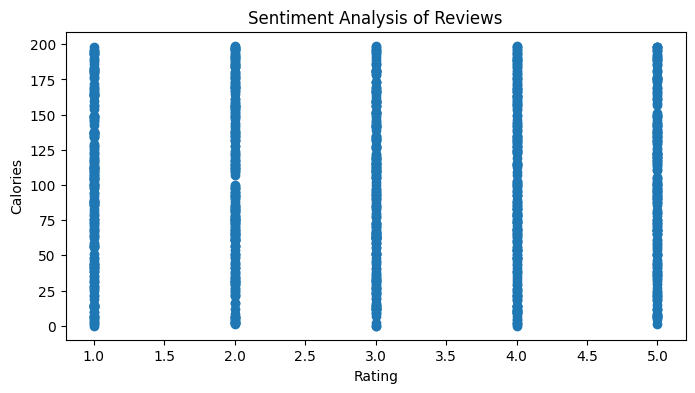

In [163]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.scatter(X["rating"], X["calerioes"])
plt.xlabel("Rating")
plt.ylabel("Calories")
plt.title("Sentiment Analysis of Reviews")
plt.show()